In [1]:
import numpy as np


In [2]:
DATA_DIR = '/srv/scratch/z5502183/AVISO_0.125/'


In [3]:
import xarray as xr

ds = xr.open_dataset(DATA_DIR + 'AVISO_0.125_EAC_1994.nc')

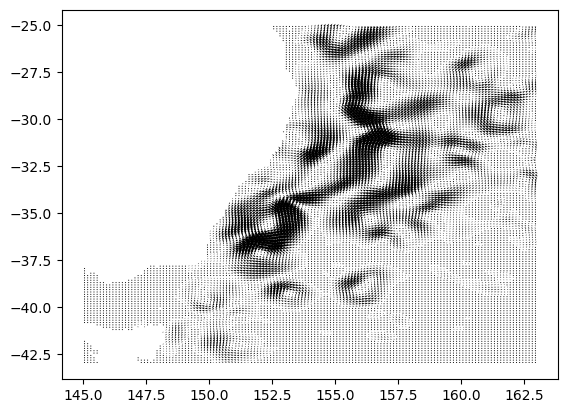

In [4]:
import matplotlib.pyplot as plt
plt.quiver(ds.longitude, ds.latitude,
           ds.ugosa.isel(time=0), ds.vgosa.isel(time=0))
plt.show()

In [5]:
ds.time

<xarray.DataArray 'time' (time: 364)> Size: 3kB
array(['1994-01-02T00:00:00.000000000', '1994-01-03T00:00:00.000000000',
       '1994-01-04T00:00:00.000000000', ..., '1994-12-29T00:00:00.000000000',
       '1994-12-30T00:00:00.000000000', '1994-12-31T00:00:00.000000000'],
      shape=(364,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1994-01-02 1994-01-03 ... 1994-12-31
Attributes:
    unit_long:      Days Since 1950-01-01
    axis:           T
    standard_name:  time
    long_name:      Time

In [10]:
ds.time.values[0]

np.datetime64('1994-01-02T00:00:00.000000000')

In [6]:
ds

<xarray.Dataset> Size: 362MB
Dimensions:    (time: 364, latitude: 144, longitude: 144)
Coordinates:
  * latitude   (latitude) float32 576B -42.94 -42.81 -42.69 ... -25.19 -25.06
  * longitude  (longitude) float32 576B 145.1 145.2 145.3 ... 162.7 162.8 162.9
  * time       (time) datetime64[ns] 3kB 1994-01-02 1994-01-03 ... 1994-12-31
Data variables:
    sla        (time, latitude, longitude) float64 60MB ...
    ugos       (time, latitude, longitude) float64 60MB ...
    ugosa      (time, latitude, longitude) float64 60MB ...
    vgos       (time, latitude, longitude) float64 60MB ...
    vgosa      (time, latitude, longitude) float64 60MB ...
    adt        (time, latitude, longitude) float64 60MB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

AVISO_SRC = PROJECT_ROOT / "src"
SEACOFS_SRC = PROJECT_ROOT.parent / "seacofs_eddy_dataset_modular" / "src"
for source in (AVISO_SRC, SEACOFS_SRC):
    if str(source) not in sys.path:
        sys.path.insert(0, str(source))

PROJECT_ROOT

PosixPath('/home/z5297792/UNSW-PhD/aviso_eddy_dataset')

In [3]:
from aviso_eddy_dataset.config import load_config
from aviso_eddy_dataset.pipeline import STAGES, run_all, run_stage

LOCAL_CONFIG = PROJECT_ROOT / "config" / "local.yaml"
CONFIG_PATH = LOCAL_CONFIG if LOCAL_CONFIG.exists() else PROJECT_ROOT / "config" / "example.yaml"
config = load_config(CONFIG_PATH)

print(f"Config: {CONFIG_PATH}")
print(f"Input:  {config.data_root}")
print(f"Output: {config.output_root}")

Config: /home/z5297792/UNSW-PhD/aviso_eddy_dataset/config/local.yaml
Input:  /srv/scratch/z5502183/AVISO_0.125
Output: /srv/scratch/z5297792/aviso_eddy_dataset


In [4]:
import pandas as pd

output_dirs = {
    "detections": config.output_root / "detections",
    "surface_eddies": config.output_root / "surface_eddies",
    "tracked": config.output_root / "tracked",
    "processed": config.output_root / "processed",
}

pd.DataFrame(
    [
        {
            "stage": name,
            "path": str(path),
            "parquet_files": len(list(path.glob("*.parquet"))) if path.exists() else 0,
        }
        for name, path in output_dirs.items()
    ]
)

,stage,path,parquet_files
0,detections,/srv/scratch/z5297792/aviso_eddy_dataset/detec...,26
1,surface_eddies,/srv/scratch/z5297792/aviso_eddy_dataset/surfa...,26
2,tracked,/srv/scratch/z5297792/aviso_eddy_dataset/tracked,0
3,processed,/srv/scratch/z5297792/aviso_eddy_dataset/proce...,0


In [5]:
detection_files = sorted((config.output_root / "detections").glob("source=*.parquet"))

if detection_files:
    detection_counts = []
    for path in detection_files:
        frame = pd.read_parquet(path, columns=["Day", "Cyc"])
        detection_counts.append(
            {
                "partition": path.stem,
                "rows": len(frame),
                "first_day": frame.Day.min() if not frame.empty else pd.NA,
                "last_day": frame.Day.max() if not frame.empty else pd.NA,
                "AE": int(frame.Cyc.eq("AE").sum()),
                "CE": int(frame.Cyc.eq("CE").sum()),
            }
        )
    display(pd.DataFrame(detection_counts))
else:
    print(f"No detection files found in {config.output_root / 'detections'}")

,partition,rows,first_day,last_day,AE,CE
0,source=AVISO_0.125_EAC_1994,26312,16072,16435,12765,13547
1,source=AVISO_0.125_EAC_1995,28743,16436,16800,13479,15264
2,source=AVISO_0.125_EAC_1996,26198,16801,17166,11950,14248
3,source=AVISO_0.125_EAC_1997,29028,17167,17531,13699,15329
4,source=AVISO_0.125_EAC_1998,27337,17532,17896,12929,14408
5,source=AVISO_0.125_EAC_1999,27775,17897,18261,13100,14675
6,source=AVISO_0.125_EAC_2000,29658,18262,18627,14012,15646
7,source=AVISO_0.125_EAC_2001,28887,18628,18992,13633,15254
8,source=AVISO_0.125_EAC_2002,31589,18993,19357,14736,16853
9,source=AVISO_0.125_EAC_2003,31933,19358,19722,14300,17633


In [6]:
for name, path in {
    "tracked": config.output_root / "tracked" / "eddy_tracks.parquet",
    "processed": config.output_root / "processed" / "eddy_dataset_processed.parquet",
}.items():
    if path.exists():
        frame = pd.read_parquet(path)
        print(f"{name}: {len(frame):,} rows, {frame['Eddy'].nunique() if 'Eddy' in frame else 0:,} eddies")
        display(frame.head())
    else:
        print(f"Missing {name} output: {path}")

Missing tracked output: /srv/scratch/z5297792/aviso_eddy_dataset/tracked/eddy_tracks.parquet
Missing processed output: /srv/scratch/z5297792/aviso_eddy_dataset/processed/eddy_dataset_processed.parquet


In [7]:
files = sorted((config.output_root / "detections").glob("*.parquet"))

df_nenc = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_nenc

,Day,Date,source_file,nxc,nyc,Cyc,nic,njc
0,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1567.0,1982.0,CE,136,143
1,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,767.0,1974.0,CE,67,142
2,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,974.0,1974.0,CE,85,142
3,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1107.0,1887.0,AE,96,136
4,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1355.0,1822.0,CE,118,131
...,...,...,...,...,...,...,...,...
742798,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,933.0,87.0,AE,81,6
742799,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1122.0,58.0,CE,98,4
742800,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,794.0,32.0,AE,69,2
742801,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,648.0,5.0,AE,56,0


In [9]:
import matplotlib.pyplot as plt

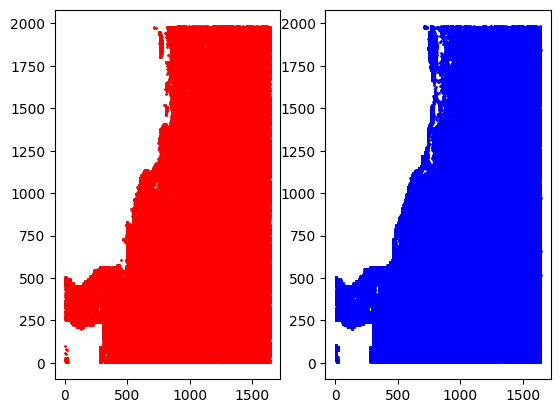

In [17]:
fig, axs = plt.subplots(1,2)
for ax, cyc in zip(axs, ['AE', 'CE']):
    df = df_nenc[df_nenc.Cyc==cyc].copy()
    ax.scatter(df.nxc, df.nyc, s=1, color='r' if cyc=='AE' else'b')

In [18]:
files = sorted((config.output_root / "surface_eddies").glob("*.parquet"))

df_doppio = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_doppio

,Day,Date,source_file,nxc,nyc,nCyc,nic,njc,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1567.0,1982.0,CE,136,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,767.0,1974.0,CE,67,142,767.718834,1976.349724,-0.000024,3.288721,0.586852,0.408790,-0.000006,-0.000006,88.459215,22.083919,32.230302
2,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,974.0,1974.0,CE,85,142,973.702299,1973.349918,-0.000017,1.048337,-0.451749,1.148560,-0.000008,-0.000007,137.514679,62.790136,80.571764
3,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1107.0,1887.0,AE,96,136,1105.134190,1885.836381,0.000013,1.229578,-0.708157,1.221140,0.000005,0.000004,149.418754,-46.614764,84.136642
4,16072,1994-01-02,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1355.0,1822.0,CE,118,131,1355.292899,1821.215118,-0.000012,1.044482,-0.150903,0.979214,-0.000006,-0.000006,78.259261,17.599157,51.458101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742798,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,933.0,87.0,AE,81,6,933.062563,87.951027,0.000003,1.502311,0.097828,0.672012,0.000002,0.000002,135.510185,-14.465946,51.613056
742799,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,1122.0,58.0,CE,98,4,1121.777385,58.270893,-0.000006,1.350279,0.119795,0.751216,-0.000003,-0.000004,69.917469,8.725516,50.307752
742800,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,794.0,32.0,AE,69,2,793.005124,31.317689,0.000009,0.921379,-0.574825,1.443948,0.000004,0.000004,68.801019,-8.866942,44.235342
742801,25260,2019-02-28,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...,648.0,5.0,AE,56,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


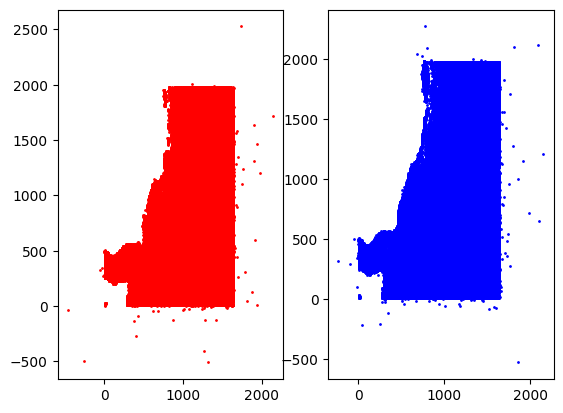

In [20]:
fig, axs = plt.subplots(1,2)
for ax, cyc in zip(axs, ['AE', 'CE']):
    df = df_doppio[df_doppio.nCyc==cyc].copy()
    ax.scatter(df.xc, df.yc, s=1, color='r' if cyc=='AE' else'b')

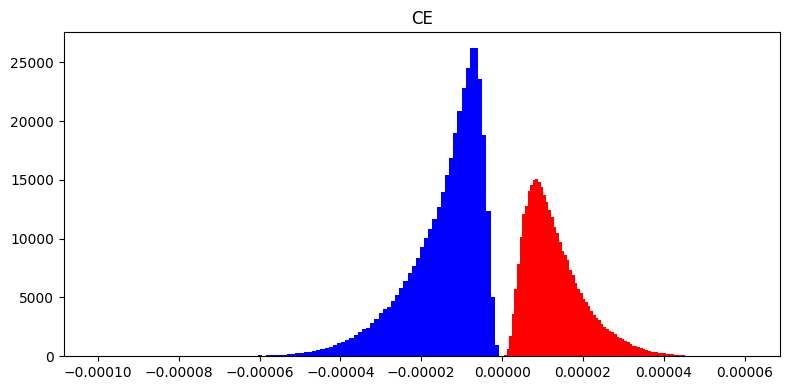

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

for cyc in ['AE', 'CE']:
    df = df_doppio[df_doppio.nCyc == cyc]
    ax.hist(df.w, color='r' if cyc == 'AE' else 'b', bins=100)
    ax.set_title(cyc)

plt.tight_layout()

In [24]:
df.w

0              NaN
1        -0.000024
2        -0.000017
4        -0.000012
5        -0.000013
            ...   
742792   -0.000016
742796   -0.000008
742797   -0.000004
742799   -0.000006
742802         NaN
Name: w, Length: 395911, dtype: float64